# Gridlock Final Architecture - Model v2 (Remediated)
This notebook directly addresses the data engineering and modeling flaws from the previous iteration.

**Key Upgrades in this version:**
1. **Log-Scaling Duration:** Prevents the Step-Function dominance caused by extreme traffic delays.
2. **K-Means Clustering:** Replaces `pd.qcut` to objectively group impact levels by real mathematical boundaries instead of forcing equal-sized bins.
3. **Target Leakage Removed:** Removed `priority` from `X_train` so the AI learns from physical features rather than human tags.
4. **Spatial Awareness:** Re-introduced `latitude` and `longitude` so CatBoost can learn geographic bottlenecks automatically.


In [16]:
# Install catboost if not already installed
!pip install catboost

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.cluster import KMeans
from sklearn.metrics import classification_report, confusion_matrix
from catboost import CatBoostClassifier, Pool
import warnings
warnings.filterwarnings('ignore')



In [17]:
from google.colab import files
import os

uploaded = files.upload()

for fn in uploaded.keys():
  print(f'User uploaded file "{fn}"')
  # Rename the uploaded file to match the expected filename if it's different
  expected_filename = 'Astram event data_anonymized - Astram event data_anonymizedb40ac87.csv'
  if fn != expected_filename:
      os.rename(fn, expected_filename)
      print(f'Renamed "{fn}" to "{expected_filename}"')


Saving Astram event data_anonymized - Astram event data_anonymizedb40ac87.csv to Astram event data_anonymized - Astram event data_anonymizedb40ac87 (1).csv
User uploaded file "Astram event data_anonymized - Astram event data_anonymizedb40ac87 (1).csv"
Renamed "Astram event data_anonymized - Astram event data_anonymizedb40ac87 (1).csv" to "Astram event data_anonymized - Astram event data_anonymizedb40ac87.csv"


In [18]:
# 1. Load Data
# Ensure the dataset is in the same directory as this notebook
try:
    df = pd.read_csv('Astram event data_anonymized - Astram event data_anonymizedb40ac87.csv')
    df.columns = df.columns.str.strip()
    print("Dataset loaded successfully.")
except FileNotFoundError:
    print("Please upload your dataset to the same folder and update the filename if necessary.")

Dataset loaded successfully.


In [19]:
# 2. Data Cleaning & Feature Engineering
df['start_datetime'] = pd.to_datetime(df['start_datetime'], errors='coerce')
df['closed_datetime'] = pd.to_datetime(df['closed_datetime'], errors='coerce')

# Calculate Duration
df['duration_minutes'] = (df['closed_datetime'] - df['start_datetime']).dt.total_seconds() / 60
df = df[df['duration_minutes'].notna() & (df['duration_minutes'] > 0)]

# Trim 99th percentile outliers (Abandoned events)
q99 = df['duration_minutes'].quantile(0.99)
df = df[df['duration_minutes'] <= q99]

# Time Features
df['hour'] = df['start_datetime'].dt.hour
df['dayofweek'] = df['start_datetime'].dt.dayofweek
df['month'] = df['start_datetime'].dt.month
df['is_weekend'] = (df['dayofweek'] >= 5).astype(int)


In [20]:
# 3. New Target Engineering (The Fix)

# Flaw Fix 1: Use Log-Scale for duration to respect time differences dynamically
log_duration = np.log1p(df['duration_minutes'])
duration_norm = (log_duration - log_duration.min()) / (log_duration.max() - log_duration.min())

# Map priority for target construction ONLY
priority_map = {'low': 1, 'medium': 2, 'high': 3, 'critical': 4}
priority_norm = df['priority'].astype(str).str.lower().map(priority_map).fillna(2) / 4
closure = df['requires_road_closure'].astype(int)

# Re-weighted Formula
df['impact_score'] = (0.5 * duration_norm) + (0.3 * priority_norm) + (0.2 * closure)

# Flaw Fix 2: Use K-Means instead of pd.qcut to respect mathematical grouping
kmeans = KMeans(n_clusters=4, random_state=42)
clusters = kmeans.fit_predict(df[['impact_score']])

# Map cluster centers to correct categorical labels
cluster_centers = kmeans.cluster_centers_.flatten()
sorted_idx = np.argsort(cluster_centers)
label_mapping = {sorted_idx[0]: 'Low', sorted_idx[1]: 'Medium', sorted_idx[2]: 'High', sorted_idx[3]: 'Critical'}
df['impact_level'] = [label_mapping[c] for c in clusters]

print("New Objective Target Distribution (K-Means):")
print(df['impact_level'].value_counts())


New Objective Target Distribution (K-Means):
impact_level
Medium      1515
Low          818
High         435
Critical     326
Name: count, dtype: int64


In [21]:
# 4. Feature Selection (Removing Leakage & Adding Spatial)

# Flaw Fix 3 & 4: 'priority' REMOVED to prevent leakage. Added 'latitude' & 'longitude'.
cat_features = ['event_type', 'event_cause', 'requires_road_closure', 'veh_type', 'corridor', 'zone', 'junction']
num_features = ['latitude', 'longitude', 'hour', 'dayofweek', 'month', 'is_weekend']
features = cat_features + num_features

# Clean missing values safely for CatBoost
for col in cat_features:
    df[col] = df[col].astype(str).fillna('Unknown')
    # Convert 'nan' strings back to 'Unknown' just in case
    df[col] = df[col].replace('nan', 'Unknown')

for col in num_features:
    df[col] = pd.to_numeric(df[col], errors='coerce')
    df[col] = df[col].fillna(df[col].median())

X = df[features]
y = df['impact_level']

# Stratified Split to ensure representation across all classes
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)


In [22]:
# 5. Model Training (CatBoost)
cat_idx = [X.columns.get_loc(c) for c in cat_features]

train_pool = Pool(X_train, y_train, cat_features=cat_idx)
test_pool = Pool(X_test, y_test, cat_features=cat_idx)

# Initialize CatBoost - Tuned for Multiclass Classification
model = CatBoostClassifier(
    iterations=500,
    learning_rate=0.08,
    depth=6,
    loss_function='MultiClass',
    eval_metric='Accuracy',
    random_seed=42,
    od_type='Iter',
    od_wait=20,
    verbose=50
)

print("Starting Model Training...")
model.fit(train_pool, eval_set=test_pool)


Starting Model Training...
0:	learn: 0.7393939	test: 0.7334410	best: 0.7334410 (0)	total: 80.5ms	remaining: 40.2s
Stopped by overfitting detector  (20 iterations wait)

bestTest = 0.7479806139
bestIteration = 6

Shrink model to first 7 iterations.


CatBoostClassifier(depth=6, eval_metric='Accuracy', iterations=500, learning_rate=0.08, loss_function='MultiClass', od_type='Iter', od_wait=20, random_seed=42, verbose=50)


--- Classification Report ---
              precision    recall  f1-score   support

    Critical       0.42      0.72      0.53        65
        High       0.51      0.41      0.46        87
         Low       0.94      0.76      0.84       164
      Medium       0.84      0.84      0.84       303

    accuracy                           0.75       619
   macro avg       0.68      0.69      0.67       619
weighted avg       0.78      0.75      0.75       619



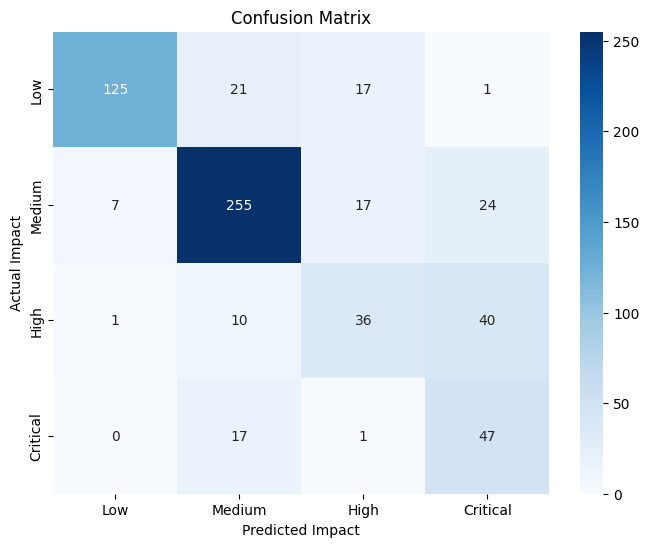

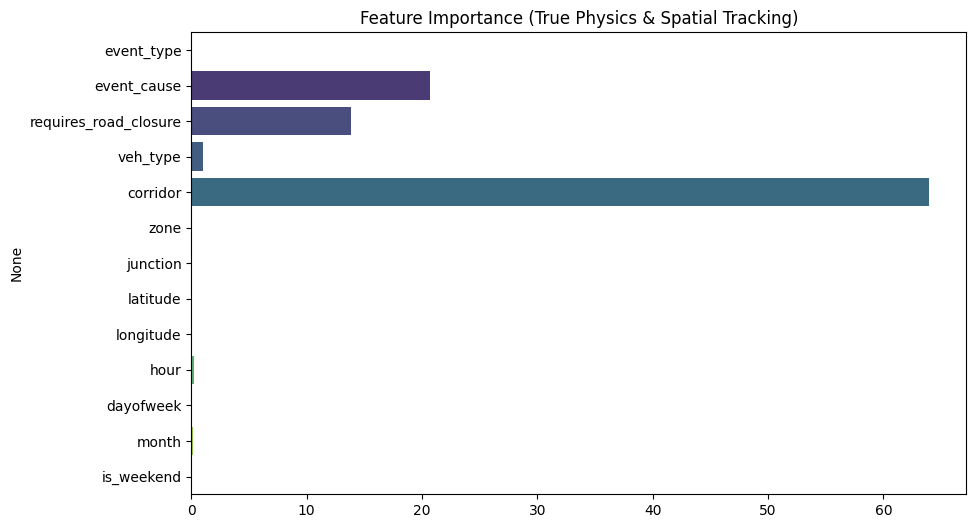

In [23]:
# 6. Evaluation & Feature Importance
y_pred = model.predict(X_test)
print("\n--- Classification Report ---")
print(classification_report(y_test, y_pred))

# Plot Confusion Matrix
plt.figure(figsize=(8,6))
cm = confusion_matrix(y_test, y_pred, labels=['Low', 'Medium', 'High', 'Critical'])
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Low', 'Medium', 'High', 'Critical'], yticklabels=['Low', 'Medium', 'High', 'Critical'])
plt.title('Confusion Matrix')
plt.ylabel('Actual Impact')
plt.xlabel('Predicted Impact')
plt.show()

# Plot Feature Importance
feat_imp = model.get_feature_importance()
plt.figure(figsize=(10,6))
sns.barplot(x=feat_imp, y=X.columns, palette='viridis')
plt.title('Feature Importance (True Physics & Spatial Tracking)')
plt.show()


In [24]:
# 7. Actionable Output (Resource Mapping Engine)
import json

# Your dynamic allocation JSON mapping
resource_map = {
    "Low": {"police": 2, "barricades": 4, "diversion": "No"},
    "Medium": {"police": 5, "barricades": 10, "diversion": "Partial"},
    "High": {"police": 10, "barricades": 20, "diversion": "Required"},
    "Critical": {"police": 20, "barricades": 40, "diversion": "Mandatory"}
}

# Simulating a live event passing through the system
sample_event = X_test.iloc[[0]]
predicted_impact = model.predict(sample_event)[0][0]
allocation = resource_map[predicted_impact]

print("🚨 NEW ASTRAM EVENT DETECTED 🚨")
print("---------------------------------")
print("Event Context:")
print(sample_event.T)
print(f"\n>> Predicted Impact Level: {predicted_impact}")
print(f">> Recommended Action Plan: {json.dumps(allocation, indent=2)}")

# Save Model and mapping to deployment files
model.save_model("remediated_traffic_model.cbm")
with open("resource_map.json", "w") as f:
    json.dump(resource_map, f)
print("\n[SUCCESS] Model and Resource mapping saved for production.")


🚨 NEW ASTRAM EVENT DETECTED 🚨
---------------------------------
Event Context:
                                    6224
event_type                     unplanned
event_cause            vehicle_breakdown
requires_road_closure              False
veh_type                     private_car
corridor                     ORR North 2
zone                        North Zone 2
junction                      BEL Circle
latitude                       13.044318
longitude                      77.556747
hour                                   3
dayofweek                              6
month                                 11
is_weekend                             1

>> Predicted Impact Level: Medium
>> Recommended Action Plan: {
  "police": 5,
  "barricades": 10,
  "diversion": "Partial"
}

[SUCCESS] Model and Resource mapping saved for production.
